# 02. Feature Engineering

## Goal

This notebook transforms the raw housing data into a model-ready feature set.

The purpose is not only to improve predictive performance, but also to make the feature space more robust and interpretable by:
- handling outliers carefully,
- treating missingness semantically,
- constructing domain-informed features,
- and preparing a cleaner input space for downstream modeling.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    
from feature import (
    remove_outliers,
    impute_missing_values,
    add_engineered_features,
    encode_features,
)

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


## 1. Outlier Detection and Handling

EDA suggested that some observations may be highly unusual and potentially harmful for stable model fitting.

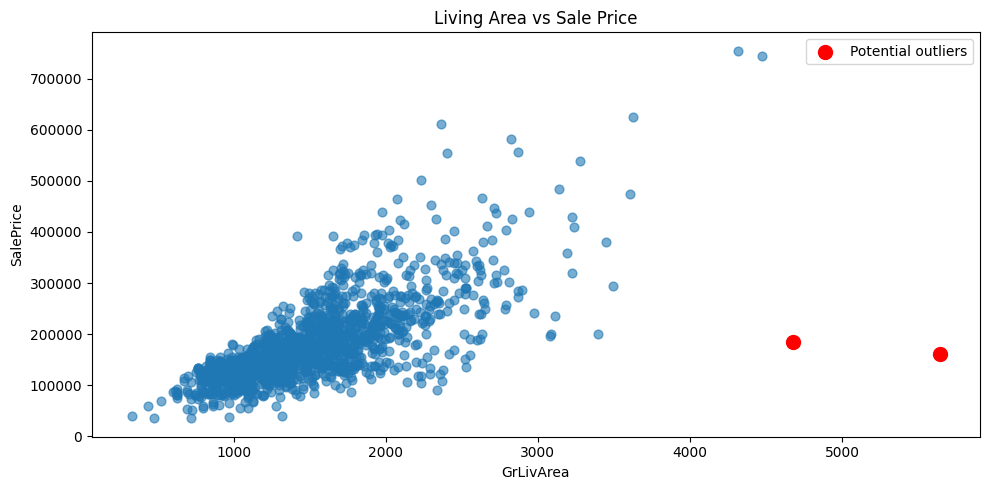

Potential outliers identified: 2


,GrLivArea,SalePrice
523,4676,184750
1298,5642,160000


In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.6, s=40)

outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
ax.scatter(
    outliers["GrLivArea"],
    outliers["SalePrice"],
    color="red",
    s=100,
    label="Potential outliers",
    zorder=5,
)

ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
ax.set_title("Living Area vs Sale Price")
ax.legend()
plt.tight_layout()
plt.show()

print("Potential outliers identified:", len(outliers))
outliers[["GrLivArea", "SalePrice"]]

### Interpretation

Most observations follow a positive relationship between living area and sale price. However, a few houses have extremely large living areas but unusually low sale prices. These observations are likely atypical cases or data anomalies and may distort downstream regression models.

Following this logic, I remove a small number of extreme cases using transparent, rule-based criteria instead of aggressive mass filtering.

In [3]:
print("Before outlier removal:", train.shape)

train_clean = remove_outliers(train)

print("After outlier removal:", train_clean.shape)
print("Removed rows:", train.shape[0] - train_clean.shape[0])

Before outlier removal: (1460, 81)
After outlier removal: (1451, 81)
Removed rows: 9


## 2. Target Transformation

The target variable `SalePrice` is strongly right-skewed. To stabilize variance and make the regression target more suitable for modeling, I apply a log transformation using `log1p`.

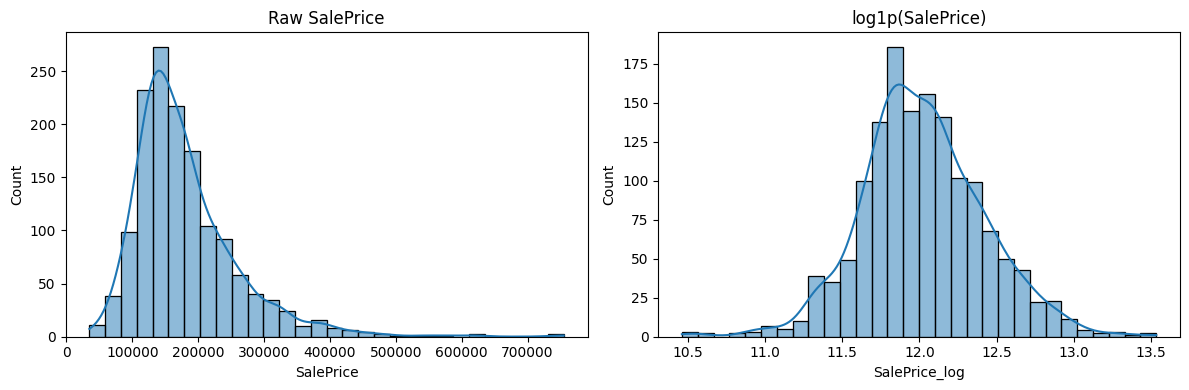

In [4]:
train_clean["SalePrice_log"] = np.log1p(train_clean["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_clean["SalePrice"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Raw SalePrice")

sns.histplot(train_clean["SalePrice_log"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")

plt.tight_layout()
plt.show()

## 3. Combine Train and Test for Consistent Preprocessing

To ensure that missing-value handling, feature construction, and categorical encoding remain consistent across train and test sets, I combine them before preprocessing.

This is a standard practical step in public tabular ML workflows, especially when applying one-hot encoding.

In [5]:
ntrain = train_clean.shape[0]
ntest = test.shape[0]

y_train = train_clean["SalePrice_log"].values
all_data = pd.concat(
    [train_clean.drop(["SalePrice", "SalePrice_log"], axis=1), test],
    axis=0
).reset_index(drop=True)

print("Combined data shape:", all_data.shape)

Combined data shape: (2910, 80)


## 4. Missing Value Imputation

The EDA showed that missingness is highly structured rather than random.

Therefore, I do not use a single imputation rule for all variables. Instead, I apply feature-specific strategies:

- `"None"` for categorical variables where missingness indicates absence,
- `0` for numeric variables where absence can be represented numerically,
- mode imputation for selected categorical variables,
- group-based median for `LotFrontage`, using `Neighborhood` to preserve locality information.

In [6]:
all_data = impute_missing_values(all_data)

remaining_missing = all_data.isnull().sum().sum()
print("Remaining missing values:", remaining_missing)

all_data.isnull().sum()[all_data.isnull().sum() > 0].sort_values(ascending=False).head(20)

Remaining missing values: 2


Utilities    2
dtype: int64

## 5. Feature Engineering

I construct a selected set of engineered features to better capture housing structure, age, quality, and spatial utility.

Rather than adding every possible transformation from a Kaggle tutorial, I keep a subset that is interpretable and plausibly relevant to real-estate valuation.

In [7]:
all_data = add_engineered_features(all_data)

selected_new_features = [
    "TotalSF", "TotalBath", "TotalPorchSF",
    "HouseAge", "YearsSinceRemod", "GarageAge",
    "IsNew", "HasRemod", "Has2ndFloor", "HasGarage", "HasBasement", "HasFireplace",
    "OverallQual_TotalSF", "OverallQual_GrLivArea",
    "Bsmt_Ratio", "AreaPerRoom"
]

all_data[selected_new_features].head()

,TotalSF,TotalBath,TotalPorchSF,HouseAge,YearsSinceRemod,GarageAge,IsNew,HasRemod,Has2ndFloor,HasGarage,HasBasement,HasFireplace,OverallQual_TotalSF,OverallQual_GrLivArea,Bsmt_Ratio,AreaPerRoom
0,2566.0,3.5,61,5,5,5.0,0,0,1,1,1,0,17962.0,11970,0.333463,190.000000
1,2524.0,2.5,298,31,31,31.0,0,0,0,1,1,1,15144.0,7572,0.499802,180.285714
2,2706.0,3.5,42,7,6,7.0,0,1,1,1,1,1,18942.0,12502,0.339860,255.142857
3,2473.0,2.0,307,91,36,8.0,0,1,1,1,1,1,17311.0,12019,0.305578,214.625000
4,3343.0,3.5,276,8,8,8.0,0,0,1,1,1,1,26744.0,17584,0.342404,219.800000


### Why these features?

These features are designed to encode several intuitions:

- larger usable space generally increases value,
- age and remodeling history affect market appeal,
- the presence of major house components (garage, basement, fireplace) carries structural information,
- and interactions such as quality × size may better reflect pricing logic than either variable alone.

## 6. Categorical Encoding

As a baseline strategy, I use one-hot encoding for categorical variables.

This keeps the workflow transparent and makes it easier to compare linear and nonlinear models in the next stage. More advanced encoding methods could be explored later if needed.

In [8]:
all_data_encoded = encode_features(all_data)

print("Encoded data shape:", all_data_encoded.shape)
all_data_encoded.head()

Encoded data shape: (2910, 275)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,False,False,False,False,True,False,False,False,True,False


## 7. Final Modeling Tables

Finally, I reconstruct the train and test matrices after preprocessing and feature engineering.

These tables will be used in the next notebook for model comparison and interpretation.

In [9]:
X_train = all_data_encoded[:ntrain].copy()
X_test = all_data_encoded[ntrain:].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1451, 275)
X_test shape: (1459, 275)
y_train shape: (1451,)


In [10]:
processed_train = X_train.copy()
processed_train["SalePrice_log"] = y_train
processed_train.to_csv("../data/processed/train_processed.csv", index=False)

X_test.to_csv("../data/processed/test_processed.csv", index=False)

## Summary

In this notebook, I transformed the raw Ames Housing data into a model-ready feature set by:

- removing a small number of domain-inconsistent outliers,
- log-transforming the target,
- handling structured missingness semantically,
- constructing interpretable engineered features,
- and applying consistent categorical encoding.

These decisions are intended not only to improve predictive performance, but also to build a cleaner and more robust foundation for downstream modeling.